**bold text**

In [ ]:
# Part 1 - Load MNIST

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


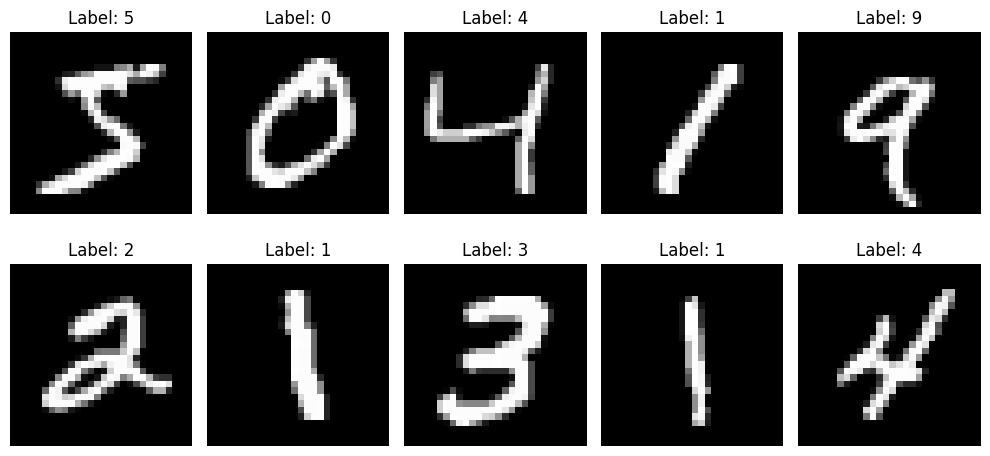

In [ ]:
# Part 2 - Visualize the Data

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Part 3 - Preprocessing

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 784)
Test shape: (10000, 784)


In [ ]:
# Build First Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Compile the Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
#  Train the Model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9261 - loss: 0.2527 - val_accuracy: 0.9680 - val_loss: 0.1113
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9663 - loss: 0.1092 - val_accuracy: 0.9708 - val_loss: 0.0924
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0736 - val_accuracy: 0.9738 - val_loss: 0.0937
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9814 - loss: 0.0574 - val_accuracy: 0.9765 - val_loss: 0.0800
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9862 - loss: 0.0431 - val_accuracy: 0.9778 - val_loss: 0.0752
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9788 - val_loss: 0.0861
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9892 - loss: 0.0307 - val_accuracy: 0.9807 - val_loss: 0.0816
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9923 - loss: 0.0236 - 

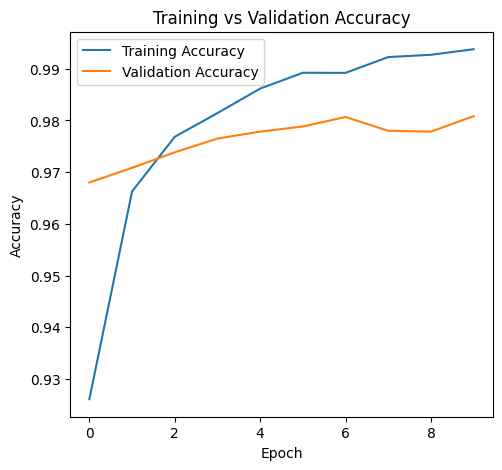

In [ ]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()



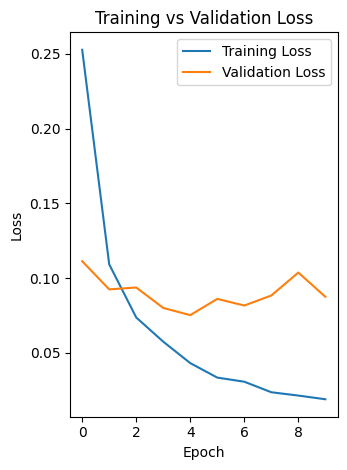

In [ ]:
# Plot Training and Validation Loss

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Part 7 - Evaluate the Model

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.09036406129598618
Test Accuracy: 0.9775999784469604


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


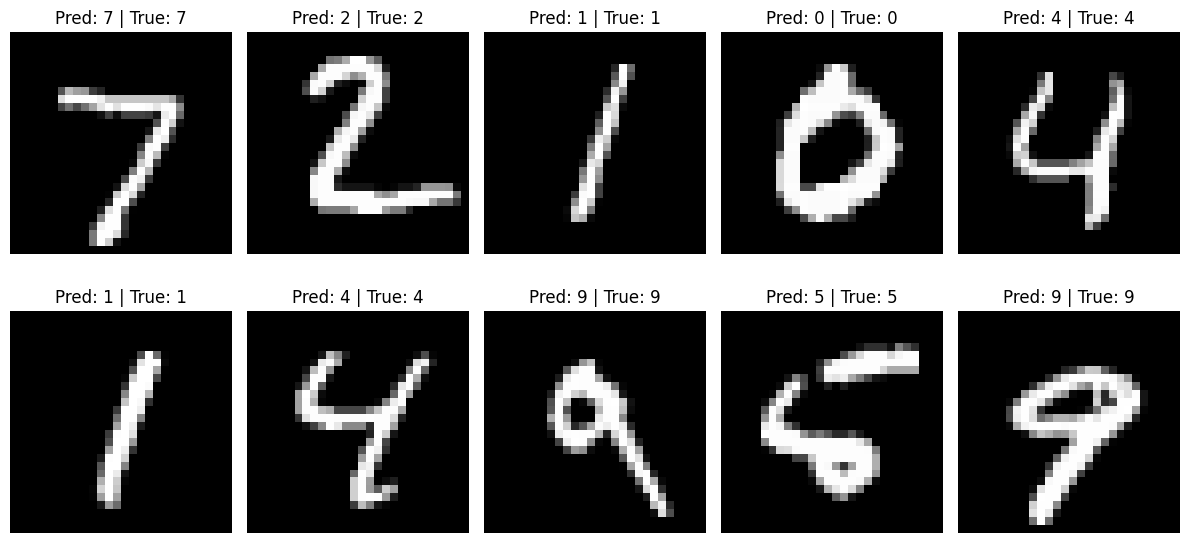

In [ ]:

# Visualize some predictions

y_pred = np.argmax(model.predict(x_test), axis=-1)

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    plt.title(
        f"Pred: {y_pred[i]} | True: {y_test[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Learning Rate

learning_rates = [0.1, 0.01, 0.001, 0.0001]

lr_results = {}

for lr in learning_rates:

    print(f"\nTraining with learning rate = {lr}")

    lr_model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    lr_model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_lr = lr_model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    test_loss, test_acc = lr_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    lr_results[lr] = test_acc

    print(f"Test Accuracy: {test_acc:.4f}")


Training with learning rate = 0.1
Test Accuracy: 0.2074

Training with learning rate = 0.01
Test Accuracy: 0.9667

Training with learning rate = 0.001
Test Accuracy: 0.9774

Training with learning rate = 0.0001
Test Accuracy: 0.9695


In [ ]:
# Compare Learning Rate Results

for lr, acc in lr_results.items():
    print(f"Learning Rate: {lr} --> Test Accuracy: {acc:.4f}")

Learning Rate: 0.1 --> Test Accuracy: 0.2074
Learning Rate: 0.01 --> Test Accuracy: 0.9667
Learning Rate: 0.001 --> Test Accuracy: 0.9774
Learning Rate: 0.0001 --> Test Accuracy: 0.9695


In [ ]:
# P Optimizers

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

optimizer_results = {}

for name, optimizer in optimizers.items():

    print(f"\nTraining with {name}")

    opt_model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    opt_model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    opt_model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    test_loss, test_acc = opt_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    optimizer_results[name] = test_acc

    print(f"Test Accuracy: {test_acc:.4f}")


Training with SGD
Test Accuracy: 0.9636

Training with Adam
Test Accuracy: 0.9760

Training with RMSprop
Test Accuracy: 0.9774


In [ ]:
# Compare Optimizers

for name, acc in optimizer_results.items():
    print(f"{name}: {acc:.4f}")

SGD: 0.9636
Adam: 0.9760
RMSprop: 0.9774


In [ ]:
# Batch Size

batch_sizes = [16, 32, 64, 128]

batch_results = {}

for batch_size in batch_sizes:

    print(f"\nTraining with batch size = {batch_size}")

    batch_model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    batch_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    batch_model.fit(
        x_train,
        y_train,
        epochs=10,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0
    )

    test_loss, test_acc = batch_model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    batch_results[batch_size] = test_acc

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")



Training with batch size = 16
Test Accuracy: 0.9740
Test Loss: 0.1193

Training with batch size = 32
Test Accuracy: 0.9756
Test Loss: 0.0945

Training with batch size = 64
Test Accuracy: 0.9773
Test Loss: 0.0852

Training with batch size = 128
Test Accuracy: 0.9775
Test Loss: 0.0794


In [ ]:
# Compare Batch Sizes

for batch_size, acc in batch_results.items():
    print(f"Batch Size: {batch_size} --> Test Accuracy: {acc:.4f}")

Batch Size: 16 --> Test Accuracy: 0.9740
Batch Size: 32 --> Test Accuracy: 0.9756
Batch Size: 64 --> Test Accuracy: 0.9773
Batch Size: 128 --> Test Accuracy: 0.9775
